In [16]:
import os
import shutil

# Tạo cấu trúc thư mục ImageFolder
os.makedirs('dataset/train_split/cats', exist_ok=True)
os.makedirs('dataset/train_split/dogs', exist_ok=True)

# Kiểm tra tệp trong thư mục 'train' vừa giải nén và di chuyển vào đúng lớp
src_path = 'train'
for filename in os.listdir(src_path):
    if filename.endswith('.jpg'):
        category = filename.split('.')[0] # 'cat' hoặc 'dog'
        if category == 'cat':
            shutil.copy(os.path.join(src_path, filename), os.path.join('dataset/train_split/cats', filename))
        elif category == 'dog':
            shutil.copy(os.path.join(src_path, filename), os.path.join('dataset/train_split/dogs', filename))

print(f"Cats: {len(os.listdir('dataset/train_split/cats'))}")
print(f"Dogs: {len(os.listdir('dataset/train_split/dogs'))}")

Cats: 12500
Dogs: 12500


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Xử lý kích thước và load dữ liệu
transform_catdog = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Load dữ liệu từ thư mục dataset/train_split vừa chuẩn bị
full_dataset = torchvision.datasets.ImageFolder(root='dataset/train_split', transform=transform_catdog)

# Chia 80% train, 20% validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_set, val_set = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader_cd = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
val_loader_cd = torch.utils.data.DataLoader(val_set, batch_size=128, shuffle=False)

# 2. Xây dựng model CNN
class CatDog_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = self.pool(torch.relu(self.conv4(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model_cd = CatDog_CNN().to(device)
criterion_cd = nn.CrossEntropyLoss()
optimizer_cd = optim.Adam(model_cd.parameters(), lr=0.001)

print("Model and Loaders ready with batch size 128.")

Model and Loaders ready with batch size 128.


In [21]:
import time

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        end_time = time.time()
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Val Accuracy: {accuracy:.2f}%, Time: {end_time - start_time:.2f}s')

# Bắt đầu huấn luyện
train_model(model_cd, train_loader_cd, val_loader_cd, criterion_cd, optimizer_cd, epochs=5)

Epoch [1/5], Loss: 0.6172, Val Accuracy: 70.78%, Time: 86.78s
Epoch [2/5], Loss: 0.5067, Val Accuracy: 77.40%, Time: 84.51s
Epoch [3/5], Loss: 0.4242, Val Accuracy: 81.36%, Time: 83.01s
Epoch [4/5], Loss: 0.3612, Val Accuracy: 79.72%, Time: 82.66s
Epoch [5/5], Loss: 0.3105, Val Accuracy: 86.70%, Time: 83.54s


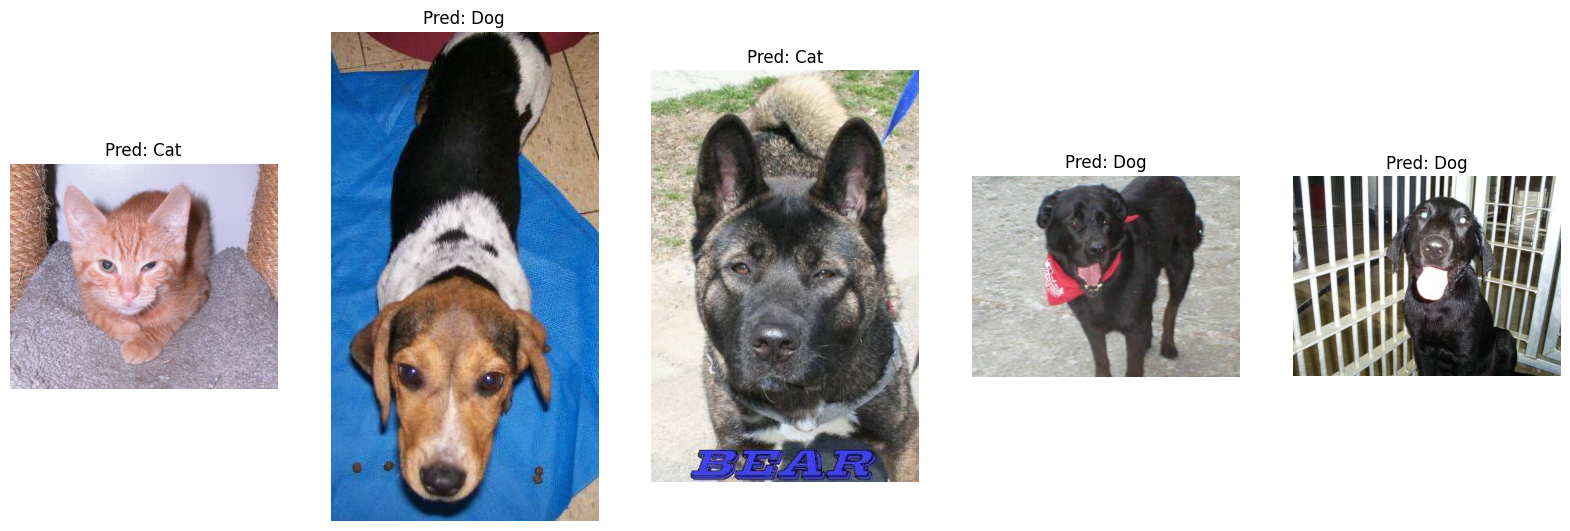

In [22]:
import matplotlib.pyplot as plt
from PIL import Image

def predict_test_images(model, test_dir, num_images=5):
    model.eval()
    images_list = [f for f in os.listdir(test_dir) if f.endswith('.jpg')][:num_images]

    fig, axes = plt.subplots(1, num_images, figsize=(20, 10))

    # Transformation tương tự như lúc train (không có augmentation)
    test_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    classes = ['Cat', 'Dog']

    with torch.no_grad():
        for i, img_name in enumerate(images_list):
            img_path = os.path.join(test_dir, img_name)
            image = Image.open(img_path)
            input_tensor = test_transform(image).unsqueeze(0).to(device)

            outputs = model(input_tensor)
            _, predicted = torch.max(outputs, 1)

            axes[i].imshow(image)
            axes[i].set_title(f"Pred: {classes[predicted.item()]}")
            axes[i].axis('off')

    plt.show()

# Chạy thử nghiệm trên thư mục test1
if os.path.exists('test1'):
    predict_test_images(model_cd, 'test1', num_images=5)
else:
    print("Thư mục 'test1' chưa được giải nén hoặc không tồn tại.")

In [23]:
# Lưu mô hình
torch.save(model_cd.state_dict(), 'cat_dog_model.pth')
print("Đã lưu mô hình vào file 'cat_dog_model.pth'")

# Hướng dẫn cách tải lại mô hình sau này:
# model = CatDog_CNN().to(device)
# model.load_state_dict(torch.load('cat_dog_model.pth'))
# model.eval()

Đã lưu mô hình vào file 'cat_dog_model.pth'
